# 🧠 1. Introdução

# 📊 EDA - Análise Exploratória de Dados

## 🎯 Objetivo

Este projeto tem como objetivo prever o preço de fechamento de ações utilizando modelos de machine learning.

Antes do treinamento dos modelos, foi realizada uma análise exploratória dos dados (EDA) para entender o comportamento da série temporal.

## 📌 Ticker analisado
ITUB4.SA (Itaú Unibanco)

Este notebook apresenta uma **Análise Exploratória de Dados (EDA)** para o ativo **ITUB4.SA**, com foco em:

- comportamento do preço ao longo do tempo
- retornos diários
- volatilidade
- médias móveis
- correlação entre variáveis
- multicolinearidade

A ideia é documentar os principais padrões dos dados e gerar insights relevantes para o problema de previsão de preços.

# 📦 2. Imports

In [35]:
import sys

In [39]:

!{sys.executable} -m pip install yfinance pandas numpy matplotlib seaborn scikit-learn statsmodels

Defaulting to user installation because normal site-packages is not writeable
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 36.8 MB/s  0:00:00eta 0:00:01
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


In [40]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

''' 
statsmodels
É uma biblioteca de Python focada em estatística e econometria, oferecendo ferramentas para análise de dados, modelagem estatística 
e testes de hipóteses.
scikit-learn → foco em ML
statsmodels → foco em interpretação estatístic
Mede multicolinearidade
y=β0​+β1​X1​+β2​X2 
'''
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 📥 3. Coleta de dados

In [9]:
ticker = "ITUB4.SA"

dados = yf.download(ticker, start="2025-04-01", end="2026-04-01")

dados.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA,ITUB4.SA
Date,,,,,
2025-04-01,27.925243,28.165365,27.720695,27.916350,12749134
2025-04-02,27.934143,28.120905,27.729595,27.898569,12147820
2025-04-03,28.432173,28.636721,27.649555,27.702915,32876673
2025-04-04,27.694025,28.227628,27.489477,28.085335,32585286
2025-04-07,27.747379,28.120903,27.160415,27.480578,33261069


## 📊 Explicação das colunas do dataset (Yahoo Finance)

Os dados foram obtidos via `yfinance` e representam informações diárias do ativo **ITUB4.SA**.

---

### 📅 Date
Data do registro de negociação.

- Representa o dia em que ocorreram as transações
- Não inclui finais de semana ou feriados (mercado fechado)

---

### 💰 Open (Preço de abertura)
Preço da primeira negociação do ativo no início do pregão.

- Indica como o mercado começou o dia
- Pode ser influenciado por notícias ou eventos fora do horário de negociação

---

### 💵 Close (Preço de fechamento)
Preço da última negociação do ativo no dia.

- É o valor mais importante para análise
- Utilizado como variável alvo (target) no modelo de previsão

---

### 📈 High (Preço máximo)
Maior preço atingido pelo ativo durante o dia.

- Representa o pico de valorização
- Ajuda a entender a volatilidade

---

### 📉 Low (Preço mínimo)
Menor preço atingido pelo ativo durante o dia.

- Representa o ponto mais baixo do dia
- Importante para análise de risco

---

### 📊 Volume
Quantidade total de ações negociadas no dia.

- Indica o nível de atividade do mercado
- Volume alto → maior interesse/investidores
- Volume baixo → menor liquidez

---


# 📊 EDA Completo - ITUB4.SA

## 🎯 Objetivo

Este notebook apresenta uma **Análise Exploratória de Dados (EDA)** para o ativo **ITUB4.SA**, com foco em:

- comportamento do preço ao longo do tempo
- retornos diários
- volatilidade
- médias móveis
- correlação entre variáveis
- multicolinearidade

A ideia é documentar os principais padrões dos dados e gerar insights relevantes para o problema de previsão de preços.

## 🧹 Preparação da base

Algumas versões do `yfinance` podem retornar colunas em formato `MultiIndex`.  
Aqui normalizamos as colunas e mantemos apenas os campos principais:

- Open
- High
- Low
- Close
- Volume

In [10]:
if isinstance(dados.columns, pd.MultiIndex):
    dados.columns = dados.columns.get_level_values(0)

dados = dados[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

for col in dados.columns:
    dados[col] = pd.to_numeric(dados[col], errors='coerce')

dados.dropna(inplace=True)

dados.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2025-04-01,27.916350,28.165365,27.720695,27.925243,12749134
2025-04-02,27.898569,28.120905,27.729595,27.934143,12147820
2025-04-03,27.702915,28.636721,27.649555,28.432173,32876673
2025-04-04,28.085335,28.227628,27.489477,27.694025,32585286
2025-04-07,27.480578,28.120903,27.160415,27.747379,33261069


## 🧪 Criação de variáveis auxiliares

Para enriquecer a análise, serão criadas novas variáveis:

- **retorno**: variação percentual diária do preço de fechamento
- **volatilidade_20**: desvio padrão móvel dos retornos em 20 dias
- **mm_20**: média móvel de 20 dias
- **mm_50**: média móvel de 50 dias
- **amplitude**: diferença entre máxima e mínima do dia
- **variacao_dia**: diferença entre fechamento e abertura

In [14]:
dados['retorno'] = dados['Close'].pct_change()
dados['volatilidade_20'] = dados['retorno'].rolling(20).std()
dados['mm_20'] = dados['Close'].rolling(20).mean()
dados['mm_50'] = dados['Close'].rolling(50).mean()
dados['amplitude'] = dados['High'] - dados['Low']
dados['variacao_dia'] = dados['Close'] - dados['Open']

dados_eda = dados.dropna().copy()
dados_eda.head()

Price,Open,High,Low,Close,Volume,retorno,volatilidade_20,mm_20,mm_50,amplitude,variacao_dia
Date,,,,,,,,,,,
2025-06-12,32.425021,33.089875,32.398068,32.892216,22525482,0.007707,0.008429,33.205069,31.385042,0.691807,0.467195
2025-06-13,32.496895,32.658617,32.263299,32.496895,14821597,-0.012019,0.008619,33.143780,31.476475,0.395318,0.000000
2025-06-16,32.820342,33.440272,32.811358,33.089878,17874002,0.018247,0.009246,33.092119,31.579590,0.628914,0.269536
2025-06-17,33.233624,33.323470,33.035965,33.287533,20133513,0.005973,0.009396,33.052566,31.676697,0.287504,0.053909
2025-06-18,33.179720,33.314490,32.982064,33.089878,20285232,-0.005938,0.008369,33.037387,31.784614,0.332425,-0.089842


## 📊 Visão geral estatística

A tabela abaixo resume métricas descritivas das variáveis numéricas.

In [18]:

dados_eda.info()
dados_eda.describe().T


<class 'pandas.DataFrame'>
DatetimeIndex: 201 entries, 2025-06-12 to 2026-03-31
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open             201 non-null    float64
 1   High             201 non-null    float64
 2   Low              201 non-null    float64
 3   Close            201 non-null    float64
 4   Volume           201 non-null    int64  
 5   retorno          201 non-null    float64
 6   volatilidade_20  201 non-null    float64
 7   mm_20            201 non-null    float64
 8   mm_50            201 non-null    float64
 9   amplitude        201 non-null    float64
 10  variacao_dia     201 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 18.8 KB


,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Open,201.0,3.733073e+01,4.709636e+00,3.095737e+01,3.381480e+01,3.584687e+01,3.957162e+01,4.862920e+01
High,201.0,3.770605e+01,4.803360e+00,3.133490e+01,3.412524e+01,3.606500e+01,3.985902e+01,4.924388e+01
Low,201.0,3.698613e+01,4.576905e+00,3.069670e+01,3.360189e+01,3.573561e+01,3.930405e+01,4.818306e+01
Close,201.0,3.735313e+01,4.707649e+00,3.098434e+01,3.384729e+01,3.584687e+01,3.957162e+01,4.894645e+01
Volume,201.0,2.417884e+07,1.011397e+07,7.190900e+06,1.702360e+07,2.152659e+07,3.034596e+07,5.435230e+07
retorno,201.0,1.532701e-03,1.453167e-02,-4.623229e-02,-7.380942e-03,2.054825e-03,1.104827e-02,4.519234e-02
volatilidade_20,201.0,1.332034e-02,3.528334e-03,7.671700e-03,1.054753e-02,1.286253e-02,1.601276e-02,2.208876e-02
mm_20,201.0,3.690810e+01,4.509790e+00,3.162934e+01,3.309212e+01,3.484050e+01,3.879120e+01,4.690727e+01
mm_50,201.0,3.593813e+01,3.751233e+00,3.138504e+01,3.288793e+01,3.462108e+01,3.784800e+01,4.440756e+01


## 📈 Evolução do preço com médias móveis

As médias móveis ajudam a suavizar o ruído do preço e destacar tendências de curto e médio prazo.

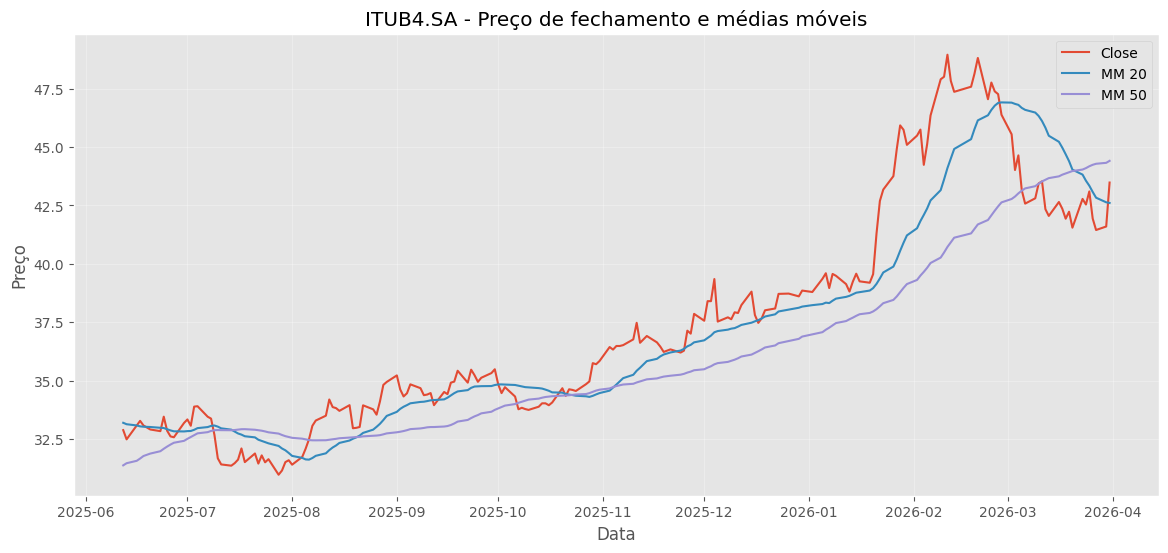

In [19]:
plt.figure(figsize=(14,6))
plt.plot(dados_eda.index, dados_eda['Close'], label='Close')
plt.plot(dados_eda.index, dados_eda['mm_20'], label='MM 20')
plt.plot(dados_eda.index, dados_eda['mm_50'], label='MM 50')
plt.title(f'{ticker} - Preço de fechamento e médias móveis')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Insight

A média móvel de 20 dias acompanha mais rapidamente as mudanças de preço, enquanto a média móvel de 50 dias apresenta uma suavização maior.

Isso mostra que o ativo possui comportamento sequencial e reforça que o problema é adequado para modelagem de séries temporais.


## 📉 Retornos diários

O retorno diário mede a variação percentual do preço de fechamento de um dia para o outro.

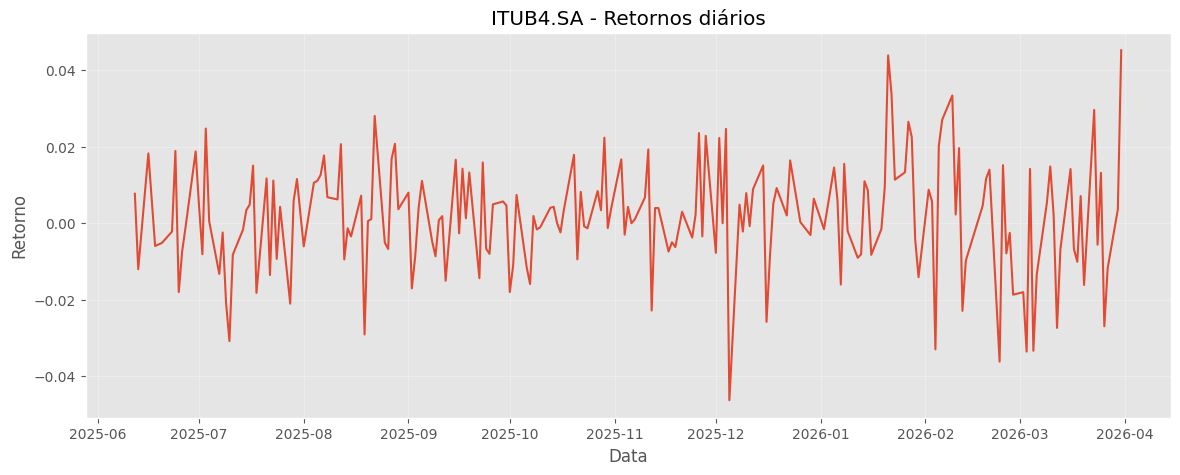

In [20]:
plt.figure(figsize=(14,5))
plt.plot(dados_eda.index, dados_eda['retorno'])
plt.title(f'{ticker} - Retornos diários')
plt.xlabel('Data')
plt.ylabel('Retorno')
plt.grid(True, alpha=0.3)
plt.show()

### Insight

Os retornos oscilam ao redor de zero, como esperado em ativos financeiros.

Picos positivos e negativos representam dias com maior impacto de mercado, indicando instabilidade pontual no comportamento do ativo.

## 📊 Distribuição dos retornos

A distribuição dos retornos permite verificar concentração dos valores, assimetria e presença de caudas longas.

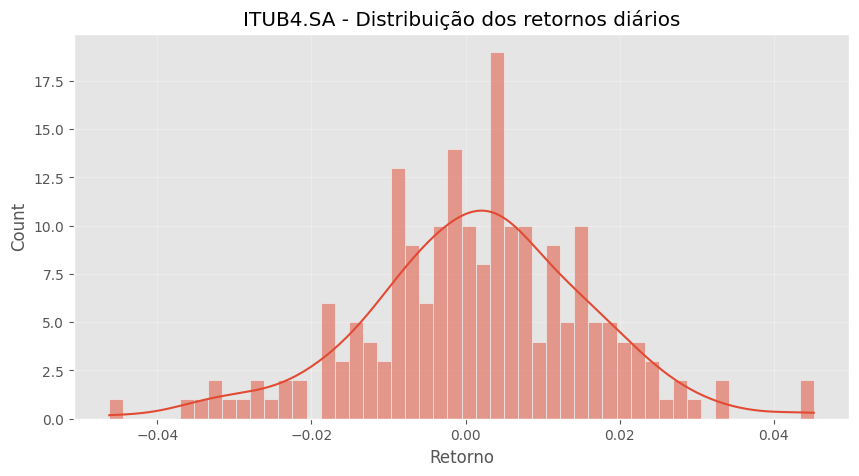

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(dados_eda['retorno'], kde=True, bins=50)
plt.title(f'{ticker} - Distribuição dos retornos diários')
plt.xlabel('Retorno')
plt.grid(True, alpha=0.3)
plt.show()

### Insight

A maior parte dos retornos tende a se concentrar próxima de zero, mas com presença de extremos em alguns períodos.

Isso indica que o ativo pode apresentar eventos de maior risco, o que pode afetar o desempenho do modelo.

## ⚠️ Volatilidade móvel

A volatilidade móvel de 20 dias é calculada com base no desvio padrão dos retornos e representa o nível de risco ao longo do tempo.

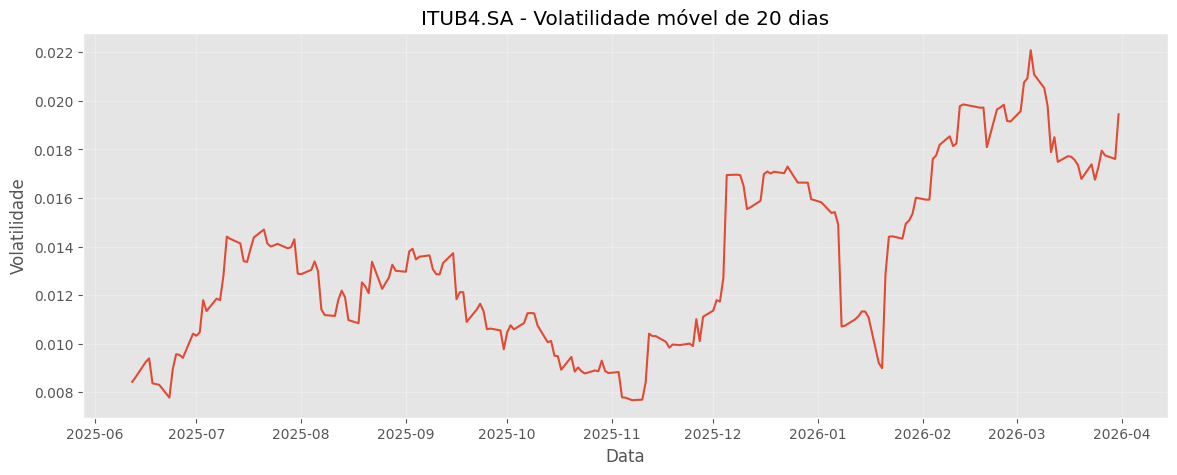

In [25]:
plt.figure(figsize=(14,5))
plt.plot(dados_eda.index, dados_eda['volatilidade_20'])
plt.title(f'{ticker} - Volatilidade móvel de 20 dias')
plt.xlabel('Data')
plt.ylabel('Volatilidade')
plt.grid(True, alpha=0.3)
plt.show()

### Insight

Períodos de maior volatilidade indicam maior incerteza e risco no mercado.

Esse comportamento pode dificultar a previsão, pois a série se torna menos estável.

## 🔗 Correlação entre variáveis

A correlação mede a intensidade e a direção da relação linear entre duas variáveis.

Valores próximos de:

- **+1** → forte correlação positiva
- **0** → ausência de correlação linear
- **-1** → forte correlação negativa

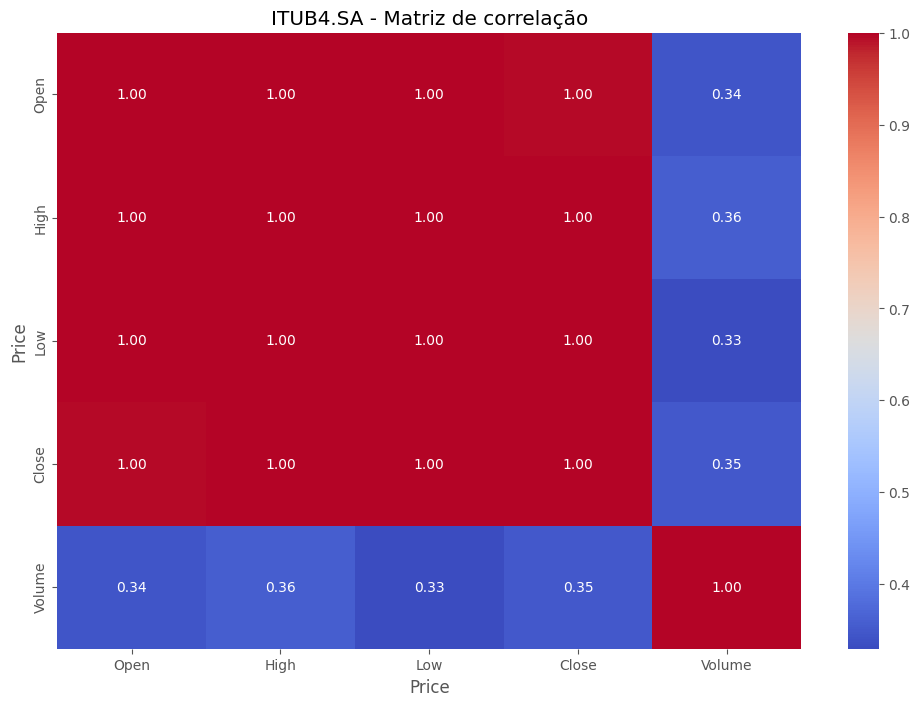

In [27]:
colunas_corr = [
    'Open', 'High', 'Low', 'Close', 'Volume' ]

corr = dados[colunas_corr].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title(f'{ticker} - Matriz de correlação')
plt.show()

### Insight

As variáveis **Open, High, Low e Close** tendem a apresentar correlação muito forte entre si, pois representam o mesmo ativo no mesmo pregão, apenas em momentos diferentes do dia.

## 📉 Exemplo visual de correlação forte

O gráfico de dispersão abaixo ajuda a demonstrar a relação entre `Open` e `Close`.

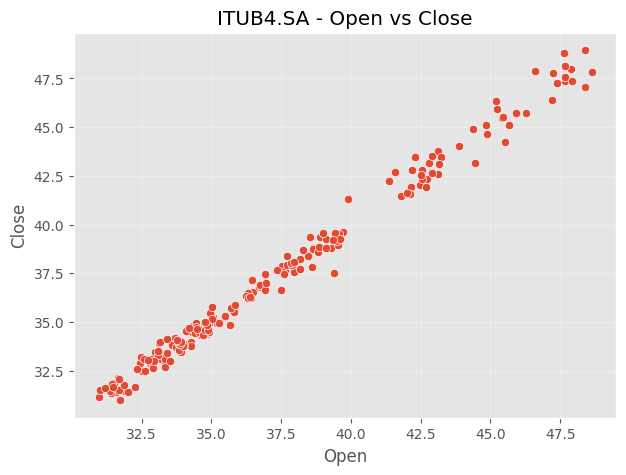

In [29]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=dados_eda['Open'], y=dados_eda['Close'])
plt.title(f'{ticker} - Open vs Close')
plt.xlabel('Open')
plt.ylabel('Close')
plt.grid(True, alpha=0.3)
plt.show()

### Insight

Se os pontos se organizam próximos de uma reta, isso indica forte dependência linear entre as variáveis.

No contexto financeiro, isso é esperado para variáveis de preço do mesmo ativo.

## 🧠 Covariância, correlação e multicolinearidade

### Covariância
A covariância mede como duas variáveis variam juntas.

- Covariância positiva: crescem juntas
- Covariância negativa: uma sobe enquanto a outra desce

### Correlação
A correlação é uma versão normalizada da covariância, facilitando a interpretação em uma escala de -1 a 1.

### Multicolinearidade
A multicolinearidade ocorre quando variáveis explicativas possuem correlação muito alta entre si.

Isso pode gerar:
- redundância de informação
- dificuldade de interpretação
- instabilidade em alguns modelos estatísticos

## 📏 Medindo multicolinearidade com VIF

O **VIF (Variance Inflation Factor)** mede o quanto a variância de uma variável explicativa está inflada pela presença de outras variáveis correlacionadas.

### Regra prática
- **VIF = 1** → sem multicolinearidade
- **VIF > 5** → atenção
- **VIF > 10** → forte multicolinearidade

In [45]:
X_vif_preco = dados_eda[['Open', 'High', 'Low', 'Close']].copy()
X_vif_preco = add_constant(X_vif_preco)

vif_preco = pd.DataFrame()
vif_preco['variavel'] = X_vif_preco.columns
vif_preco['VIF'] = [variance_inflation_factor(X_vif_preco.values, i) for i in range(X_vif_preco.shape[1])]

vif_preco

,variavel,VIF
0,const,81.694047
1,Open,452.649903
2,High,822.244523
3,Low,654.771722
4,Close,606.641939


### Insight

É esperado que as variáveis de preço apresentem VIF muito elevado, pois são altamente correlacionadas entre si.

Isso confirma a existência de multicolinearidade no conjunto de variáveis ligadas ao preço.

## 📏 VIF com conjunto ampliado de variáveis

Agora avaliamos a multicolinearidade incluindo médias móveis, volume e amplitude.

- **retorno**: variação percentual diária do preço de fechamento
- **volatilidade_20**: desvio padrão móvel dos retornos em 20 dias
- **mm_20**: média móvel de 20 dias
- **mm_50**: média móvel de 50 dias
- **amplitude**: diferença entre máxima e mínima do dia
- **variacao_dia**: diferença entre fechamento e abertura

In [48]:
X_vif_full = dados_eda[['Open', 'High', 'Low', 'Close', 'mm_20', 'mm_50', 'Volume', 'amplitude']].copy()
X_vif_full = add_constant(X_vif_full)

vif_full = pd.DataFrame()
vif_full['variavel'] = X_vif_full.columns
vif_full['VIF'] = [variance_inflation_factor(X_vif_full.values, i) for i in range(X_vif_full.shape[1])]

vif_full

/home/clavezzo/.local/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variavel,VIF
0,const,138.883852
1,Open,478.589262
2,High,inf
3,Low,inf
4,Close,609.943585
5,mm_20,35.350825
6,mm_50,19.017881
7,Volume,1.754585
8,amplitude,inf


### Insight

#### Interpretação do VIF

Os resultados do VIF mostraram valores extremamente elevados para variáveis ligadas ao preço, como `Open`, `Close`, `High`, `Low`, `mm_20`, `mm_50` e `amplitude`.

Em alguns casos, o VIF foi infinito (`inf`), o que indica dependência linear quase perfeita ou perfeita entre variáveis explicativas.

Esse comportamento era esperado, pois:

- `Open`, `High`, `Low` e `Close` representam o mesmo ativo no mesmo pregão
- `mm_20` e `mm_50` são derivadas diretamente do preço de fechamento
- `amplitude` é calculada como `High - Low`, sendo uma combinação linear exata dessas variáveis

Por outro lado, a variável `Volume` apresentou VIF baixo, indicando menor redundância e maior potencial de complementaridade para o modelo.

#### Conclusão

Os resultados confirmam a presença de **forte multicolinearidade** no conjunto de variáveis de preço.  
Isso sugere que não é recomendável utilizar simultaneamente todas essas colunas no modelo, pois muitas carregam informação repetida.

#Como melhorar a demonstração

Para mostrar um cenário “melhor”, rode um VIF com variáveis menos redundantes:

In [49]:
X_vif_melhor = dados_eda[['Close', 'Volume', 'retorno', 'volatilidade_20']].copy()
X_vif_melhor = add_constant(X_vif_melhor)

vif_melhor = pd.DataFrame()
vif_melhor['variavel'] = X_vif_melhor.columns
vif_melhor['VIF'] = [
    variance_inflation_factor(X_vif_melhor.values, i)
    for i in range(X_vif_melhor.shape[1])
]

vif_melhor

,variavel,VIF
0,const,73.000181
1,Close,2.166169
2,Volume,1.384178
3,retorno,1.051480
4,volatilidade_20,2.095984


## O que é a variável `const`

A variável `const` representa o termo constante (intercepto) adicionado ao modelo.

Ela é incluída automaticamente pela função `add_constant` para permitir que a regressão linear calcule corretamente os coeficientes.

No contexto do cálculo do VIF, a variável `const` não deve ser interpretada, pois serve apenas como suporte matemático para o modelo.

Intercepto é o β0 logo  y=β0​+β1​X1​+β2​X2

β₁, β₂ = pesos das variáveis no modelo

dizem o quanto cada variável influencia o resultado
ficam ruins quando há multicolinearidade

Se você tivesse um modelo assim:

Close=β0​+β1​⋅Open+β2​⋅Volume

interpretação:

β₁ → impacto do preço de abertura no fechamento
β₂ → impacto do volume no fechamento

## Gráfico do VIF

/home/clavezzo/.local/lib/python3.13/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


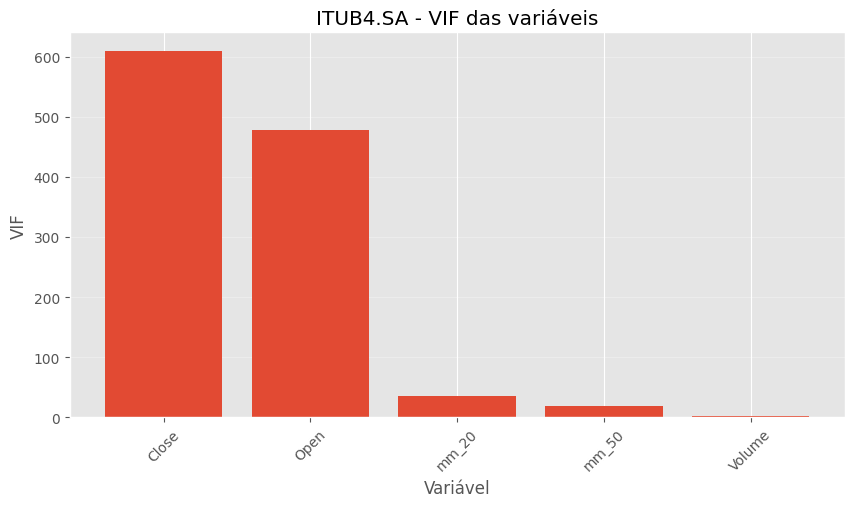

In [50]:
vif_plot = vif_full[vif_full['variavel'] != 'const'].sort_values('VIF', ascending=False)

plt.figure(figsize=(10,5))
plt.bar(vif_plot['variavel'], vif_plot['VIF'])
plt.title(f'{ticker} - VIF das variáveis')
plt.xlabel('Variável')
plt.ylabel('VIF')
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

### Insight

Variáveis com VIF muito alto indicam informação redundante.

No contexto deste projeto, isso sugere que nem todas as colunas de preço precisam ser usadas ao mesmo tempo, especialmente quando o objetivo é prever o comportamento do `Close`.

## Comparação entre preço e volatilidade normalizados

Este gráfico ajuda a comparar visualmente o comportamento do preço e da volatilidade em uma mesma escala.

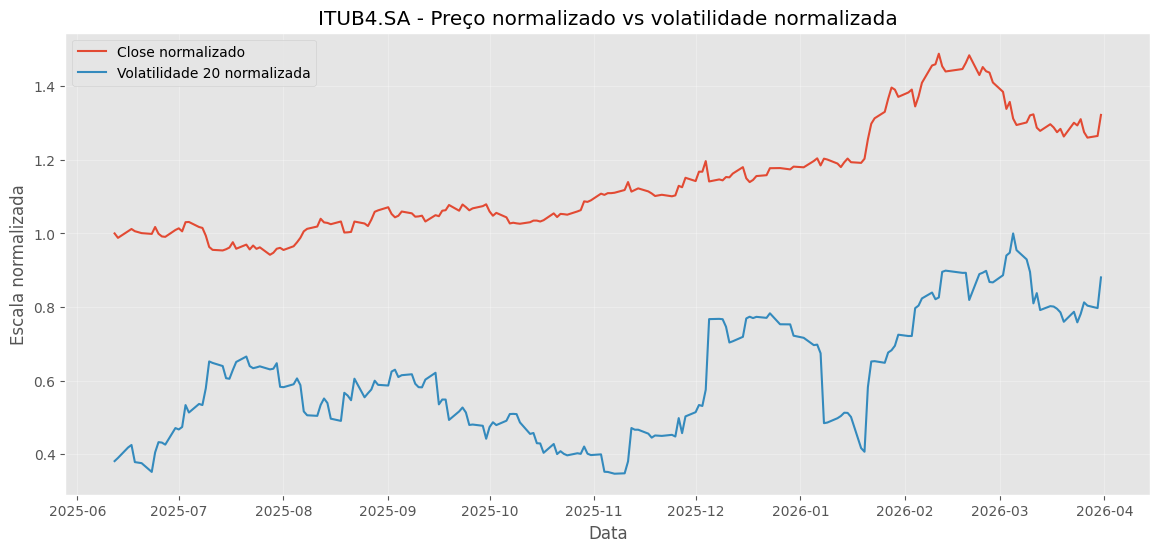

In [43]:
plt.figure(figsize=(14,6))
plt.plot(dados_eda.index, dados_eda['Close'] / dados_eda['Close'].iloc[0], label='Close normalizado')
plt.plot(dados_eda.index, dados_eda['volatilidade_20'] / dados_eda['volatilidade_20'].max(), label='Volatilidade 20 normalizada')
plt.title(f'{ticker} - Preço normalizado vs volatilidade normalizada')
plt.xlabel('Data')
plt.ylabel('Escala normalizada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Insight

Picos de volatilidade costumam aparecer em momentos de maior instabilidade do ativo.

Essa informação pode ser útil para complementar a modelagem, principalmente em cenários onde apenas o preço de fechamento não explica toda a dinâmica do mercado.

## 📦 Boxplot dos retornos

O boxplot permite identificar a dispersão dos retornos e a presença de outliers.

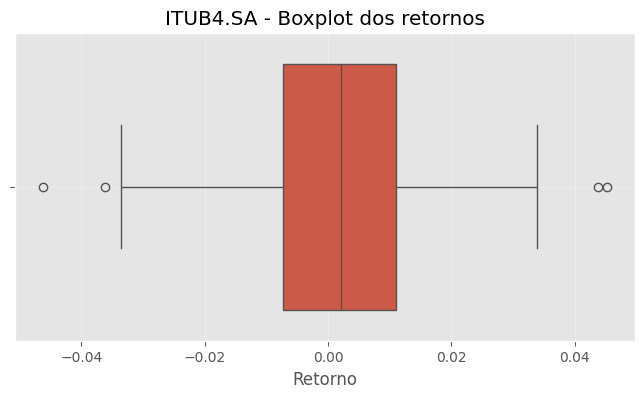

In [51]:
plt.figure(figsize=(8,4))
sns.boxplot(x=dados_eda['retorno'])
plt.title(f'{ticker} - Boxplot dos retornos')
plt.xlabel('Retorno')
plt.grid(True, alpha=0.3)
plt.show()

### Insight

Os outliers observados nos retornos representam dias com movimentos mais extremos de mercado.

Esses pontos podem impactar o treinamento dos modelos, especialmente em abordagens mais sensíveis a valores extremos.

#### Interpretação do boxplot dos retornos

O boxplot dos retornos diários permite visualizar a distribuição, dispersão e presença de valores extremos (outliers).

- **retorno**: variação percentual diária do preço de fechamento
- **volatilidade_20**: desvio padrão móvel dos retornos em 20 dias
- **mm_20**: média móvel de 20 dias
- **mm_50**: média móvel de 50 dias
- **amplitude**: diferença entre máxima e mínima do dia
- **variacao_dia**: diferença entre fechamento e abertura

A caixa vermelha → é o intervalo entre Q1 e Q3
A linha dentro da caixa → mediana
Os bigodes → linhas horizontais que saem da caixa Q1−1.5×IQReQ3+1.5×IQR <-> O que passar disso vira outlier (os pontinhos)
Os pontinhos fora → outliers

   o        |───────[  CAIXA  ]───────|        o o
          ← bigode esquerdo     bigode direito →

Estrutura do boxplot
📦 Caixa (box)
Vai do Q1 (25%) ao Q3 (75%)
Representa onde está a maior parte dos dados
a maioria dos retornos está entre ~ -1% e +1%

Linha no meio
É a mediana
Observando o gráfico → está perto de 0

#### Interpretação:
o ativo não tem tendência diária forte (normal em mercado eficiente)

Bigodes (whiskers)
Mostram a variação "normal" dos dados
Aproximadamente até ±3%

⚫ Pontos fora (outliers)
 Esses pontos são MUITO importantes

Observando o gráfico:
~ -4% / -5%
~ +4% / +5%

#### Interpretação:
dias de alta volatilidade / eventos de mercado

Observações principais:

- A mediana está próxima de zero, indicando ausência de tendência diária consistente
- A maior parte dos retornos está concentrada em um intervalo estreito, aproximadamente entre -1% e +1%
- Os "bigodes" indicam a variação típica dos retornos, que se mantém dentro de uma faixa moderada
- A presença de outliers, tanto positivos quanto negativos, indica dias de maior volatilidade e eventos atípicos no mercado

#### Implicações

Os outliers representam movimentos abruptos de preço que podem impactar o desempenho do modelo, especialmente em abordagens mais sensíveis a extremos.

Isso reforça a importância de considerar variáveis como volatilidade no processo de modelagem.

## Boxplot dos retornos - Mensal

O boxplot permite identificar a dispersão dos retornos e a presença de outliers e principalmente se há sazonalidade.

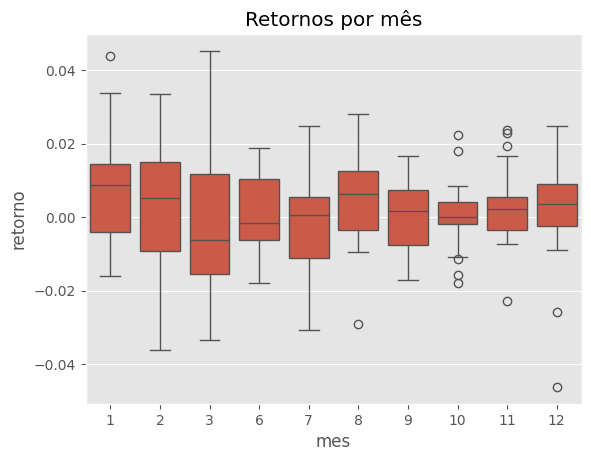

In [52]:
dados_eda['mes'] = dados_eda.index.month

sns.boxplot(x='mes', y='retorno', data=dados_eda)
plt.title("Retornos por mês")
plt.show()

### Insight

A análise dos retornos por mês não evidencia um padrão sazonal claro.

Observações:

- As medianas dos retornos permanecem próximas de zero na maioria dos meses
- A dispersão dos dados é relativamente semelhante entre os meses
- Os outliers estão distribuídos ao longo de diferentes períodos, sem concentração específica

#### Conclusão

Não há evidências de sazonalidade significativa nos retornos mensais do ativo.

O comportamento observado é mais consistente com um processo estocástico típico de mercados financeiros, onde as variações ocorrem de forma não determinística.

#### Implicação para o modelo

A ausência de sazonalidade sugere que:

- não há necessidade de incluir variáveis sazonais explícitas (como mês)
- o foco deve estar em dependência temporal e volatilidade

In [54]:
# calcular quartis
Q1 = dados_eda['retorno'].quantile(0.25)
Q3 = dados_eda['retorno'].quantile(0.75)

# IQR
IQR = Q3 - Q1

# limites
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# identificar outliers
outliers = dados_eda[
    (dados_eda['retorno'] < lower) | 
    (dados_eda['retorno'] > upper)
]

# calcular percentual
percentual_outliers = (len(outliers) / len(dados_eda)) * 100

print(f"Total de registros: {len(dados_eda)}")
print(f"Quantidade de outliers: {len(outliers)}")
print(f"Percentual de outliers: {percentual_outliers:.2f}%")

Total de registros: 201
Quantidade de outliers: 4
Percentual de outliers: 1.99%


### Insight

Os outliers foram identificados utilizando o método do intervalo interquartil (IQR), que define limites baseados na distribuição dos dados.

O percentual de outliers observado é consistente com o comportamento esperado de ativos financeiros, que apresentam eventos extremos ocasionais.

Esses valores refletem movimentos relevantes de mercado e não devem ser tratados como erro, mas sim como parte da dinâmica do ativo.

% outliers	Interpretação

< 1%	muito estável

1–5%	normal (mercado)

5–10%	alta volatilidade

> 10%	instável

# ✅ Conclusões Finais do EDA

A análise exploratória dos dados do ativo **ITUB4.SA** permitiu compreender a estrutura estatística da série temporal e identificar padrões relevantes para a modelagem.

---

## 📈 Comportamento do preço

- O ativo apresenta comportamento típico de série temporal financeira
- Observa-se variação ao longo do tempo, sem tendência linear simples
- As médias móveis evidenciam dependência temporal e ajudam a suavizar o ruído

---

## 📉 Retornos

- Os retornos diários estão concentrados próximos de zero
- Não há tendência consistente de alta ou baixa no curto prazo
- O comportamento é compatível com um processo estocástico

---

## ⚠️ Volatilidade

- Existem períodos de maior volatilidade ao longo da série
- A volatilidade não é constante, indicando mudanças no risco do ativo
- Esses períodos podem impactar a capacidade preditiva do modelo

---

## 📊 Outliers

A análise de outliers demonstra que o ativo apresenta comportamento consistente com mercados financeiros reais:

- baixa frequência de eventos extremos (**~2% dos dados**)
- presença de movimentos relevantes com alto impacto
- distribuição não normal, com caudas pesadas

Esses resultados reforçam a necessidade de modelos que considerem volatilidade e sejam robustos a eventos extremos.

#### 📈 Impacto na modelagem

A presença de outliers implica que:

- modelos podem apresentar maior erro em dias de alta volatilidade
- métricas como RMSE podem ser influenciadas por poucos pontos extremos
- abordagens mais robustas podem ser necessárias para capturar esse comportamento

---

## 🔗 Correlação entre variáveis

- As variáveis **Open, High, Low e Close** apresentam forte correlação
- As médias móveis também são altamente correlacionadas com o preço
- Isso indica redundância de informação entre as variáveis

---

## 📏 Multicolinearidade (VIF)

- O VIF apresentou valores elevados e até infinitos para variáveis de preço
- Isso confirma a presença de multicolinearidade extrema
- Variáveis derivadas (como médias móveis e amplitude) aumentam essa redundância

---

## 📅 Sazonalidade

- Não foi identificada sazonalidade significativa nos retornos mensais
- O comportamento do ativo é predominantemente não determinístico

---

## 🧠 Insights principais

- O preço carrega forte dependência temporal → adequado para modelos de séries temporais
- Variáveis de preço são altamente redundantes → cuidado na seleção de features
- Variáveis como **retorno, volatilidade e volume** agregam informação mais relevante
- A presença de outliers indica caudas pesadas (fat tails), típicas de mercados financeiros

---

## 🚀 Implicações para modelagem

Com base no EDA:

- Utilizar apenas o histórico de **Close** já captura grande parte da informação
- Evitar uso simultâneo de múltiplas variáveis altamente correlacionadas
- Incluir variáveis derivadas (retorno, volatilidade) pode melhorar o modelo
- Modelos devem ser robustos a outliers e mudanças de volatilidade
- Abordagens de séries temporais (como LSTM ou janelas temporais) são adequadas

---

## 📌 Conclusão geral

Os dados apresentam características clássicas de ativos financeiros:

- comportamento estocástico
- ausência de sazonalidade forte
- presença de eventos extremos
- alta correlação entre variáveis de preço

Essas evidências sustentam as escolhas de modelagem adotadas no projeto e reforçam a necessidade de abordagens que considerem dependência temporal e volatilidade.